In [101]:
### Ethan Johnson ###
### ATSC 528 Assigment 2 ###
### Function Fitting ###
"""
Created By    : Jared W. Marquis
Creation Date : 01 August 2022
Course        : ATSC 528 - Atmospheric Data Analysis
Assignment    : #01 - Function Fitting

Purpose:
Script to take sparse upper air observations and analyze them on a
polar stereographic map projection using function fitting.
[PUT MORE INFORMATION HERE - I.E., WHAT SPECIFIC THING IS BEING DONE]

"""
__author__    = "Jared W. Marquis"
__contact__   = "jared.marquis@und.edu"

In [134]:
### Import Required Modules (shouldn't need to change) ###
import numpy as np                 #numpy for math
import matplotlib.pyplot as plt    #matplotlib for plotting
import cartopy.crs as ccrs         #cartopy for plotting on map
import cartopy.feature as cfeature #cartopy basic shapefiles
import pandas as pd

In [135]:
### Read in observations ###
df = pd.read_csv('RAOBs_201903131200.txt', header=None, names=['station','lat','lon','z_500','udir','uspd'])
df

,station,lat,lon,z_500,udir,uspd
0,CWPL,51.47,-90.2,5460.0,285.0,29.0
1,CWQI,43.83,-66.0,5540.0,325.0,41.0
2,CWSE,53.55,-113.9,5360.0,280.0,12.0
3,CYAH,53.75,-73.6,5340.0,300.0,70.0
4,CYBK,64.30,-96.0,5220.0,95.0,17.0
...,...,...,...,...,...,...
130,KWAL,37.93,-75.4,5730.0,325.0,44.0
131,KXKF,32.37,-64.6,5620.0,300.0,46.0
132,KYAK,59.52,-139.6,5340.0,195.0,22.0
133,KYMW,46.38,-75.9,5580.0,275.0,38.0


In [136]:
### Set up analysis map with a 21x27 rectangular grid of points ###

rho = 6371.0                     # km
phi0 = np.radians(60.0)        # standard latitude
lam0 = -100.0                  # reference longitude,
m = 1 / 15_000_000             # map scale

SCALE_TOP = 1 + np.sin(phi0)  


def r_from_pole_km(lat_deg):
    phi = np.radians(lat_deg)
    return R * np.cos(phi) * SCALE_TOP / (1 + np.sin(phi))


def latlon_to_xy_cm(lat_deg, lon_deg):
    r_km = r_from_pole_km(lat_deg)
    r_map_cm = r_km * m * 100_000
    dlam = np.radians(lon_deg - lam0)
    x = r_map_cm * np.cos(dlam)
    y = r_map_cm * np.sin(dlam)
    return x, y


def xy_cm_to_latlon(x_cm, y_cm):
    r_map_cm = np.hypot(x_cm, y_cm)
    r_km = (r_map_cm / 100_000) / m
    ratio = r_km / (rho * SCALE_TOP)
    phi = np.pi / 2 - 2 * np.arctan(ratio)
    lat_deg = np.degrees(phi)
    dlam = np.arctan2(y_cm, x_cm)
    lon_deg = (lam0 + np.degrees(dlam) + 180) % 360 - 180
    return lat_deg, lon_deg


# 21 x 27 grid setup
NX, NY = 21, 27
DX = DY = 1.27                 
X0, Y0 = 25.0, -15.5           

x_vals = X0 + np.arange(NX) * DX
y_vals = Y0 + np.arange(NY) * DY


grid_lat = np.empty((NX, NY))
grid_lon = np.empty((NX, NY))
for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        lat, lon = xy_cm_to_latlon(x, y)
        grid_lat[i, j] = lat
        grid_lon[i, j] = lon

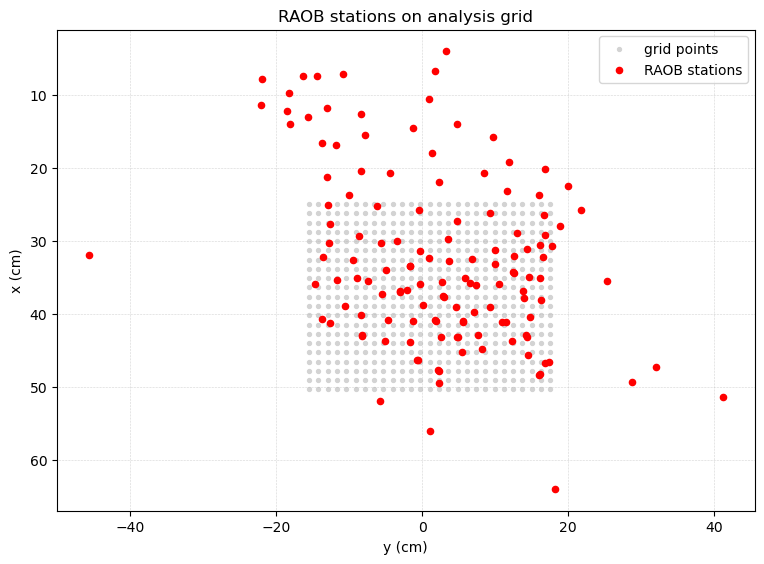

In [137]:
### convert obs lat/long to x,y (may want to plot on your analysis grid to verify)###
obs_x, obs_y = latlon_to_xy_cm(df["lat"].values, df["lon"].values)

fig, ax = plt.subplots(figsize=(9, 11))
gy, gx = np.meshgrid(y_vals, x_vals)
ax.scatter(gy, gx, s=8, color="lightgray", label="grid points", zorder=1)
ax.scatter(obs_y, obs_x, s=20, color="red", label="RAOB stations", zorder=3)

ax.set_xlabel("y (cm)")
ax.set_ylabel("x (cm)")
ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_title("RAOB stations on analysis grid")
ax.legend(loc="upper right")
ax.grid(True, linestyle=":", linewidth=0.4)
plt.show()


In [138]:
### Perform 500mb geopotential height analyses using a second order 2-d polynomial with two ###
### radii of influence (10cm & 20cm) ###

def local_poly_analysis(gx, gy, ox, oy, of, roi):
    out = np.full(gx.shape, np.nan)
    npts = np.zeros(gx.shape, dtype=int)
    for i in range(gx.shape[0]):
        for j in range(gx.shape[1]):
            dx = ox - gx[i, j]
            dy = oy - gy[i, j]
            M = (dx**2 + dy**2 <= roi**2) & np.isfinite(of)
            N = M.sum()
            npts[i, j] = N
            if N == 0:
                continue
            xk, yk, f = dx[M], dy[M], of[M]
            B = np.column_stack([np.ones(N), xk, yk, xk**2, yk**2, xk*yk])
            Mat = (B.T @ B) / N
            rhs = (B.T @ f) / N
            if np.linalg.matrix_rank(Mat) < 6:
                continue
            c = np.linalg.solve(Mat, rhs)   # [c00, c10, c01, c20, c02, c11]
            out[i, j] = c[0]
    return out, npts

gyy, gxx = np.meshgrid(y_vals, x_vals)
ox, oy = latlon_to_xy_cm(df["lat"].values, df["lon"].values)
oz = df["z_500"].values

Z10, n10 = local_poly_analysis(gxx, gyy, ox, oy, oz, roi=10.0)
Z20, n20 = local_poly_analysis(gxx, gyy, ox, oy, oz, roi=20.0)
Z6,  n6  = local_poly_analysis(gxx, gyy, ox, oy, oz, roi=6.0)

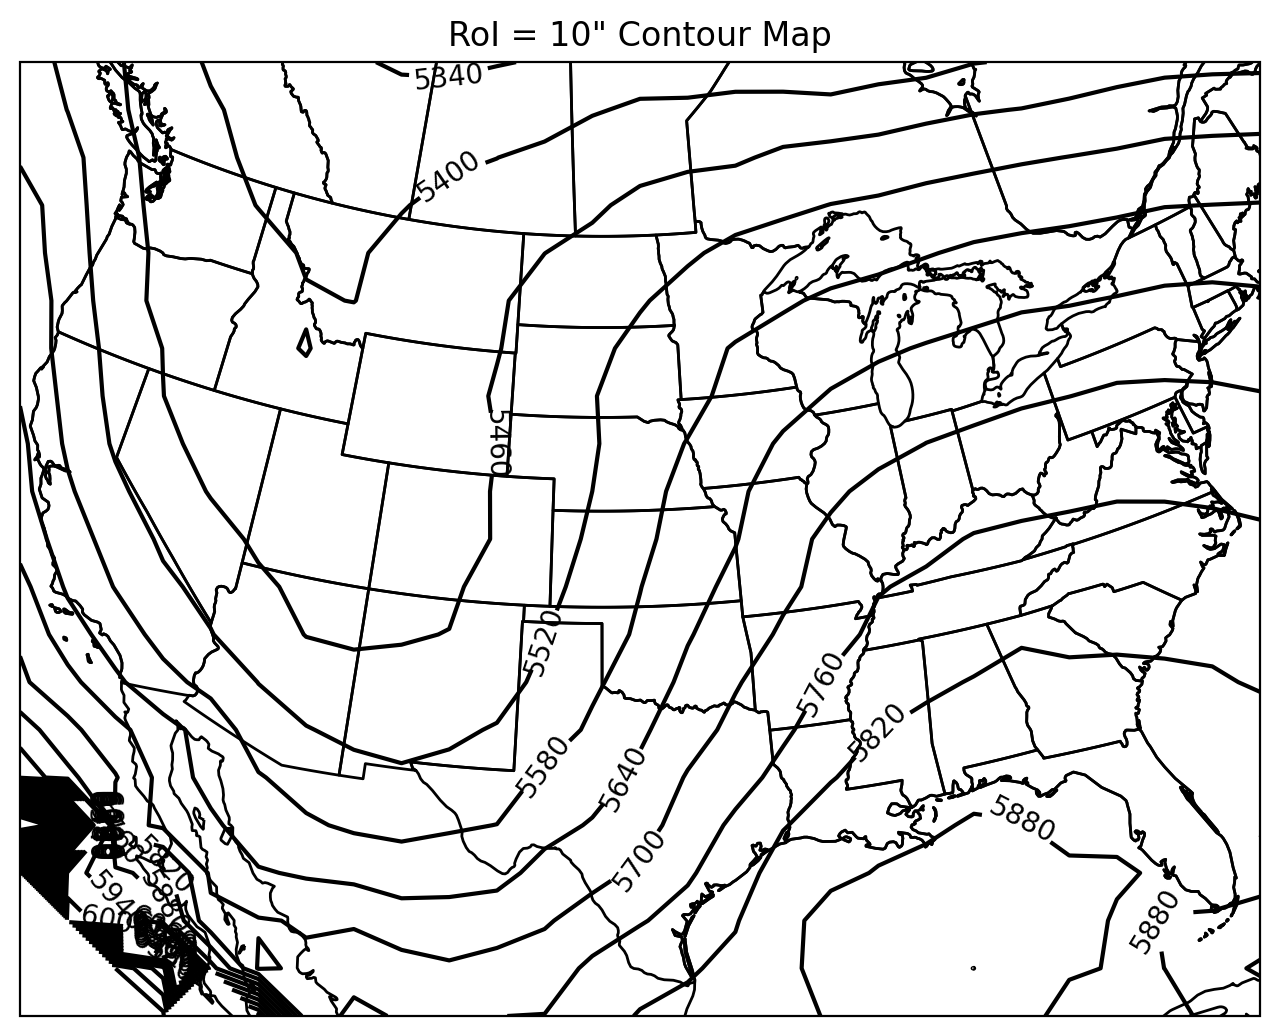

In [139]:
### Plot 500mb analyses over a map ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho*1000, semiminor_axis=rho*1000)
proj = ccrs.Stereographic(central_longitude=lam0,central_latitude=90,true_scale_latitude=60.0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)

cs1 = ax1.contour(gyy/m/100,-gxx/m/100,Z10,colors='k',levels=np.arange(0,8000,60),transform=proj)
plt.clabel(cs1,levels=np.arange(0,8000,60))
plt.title('RoI = 10" Contour Map')
#plt.savefig('Z10_contour_map.png', dpi=300,bbox_inches='tight')
plt.show()

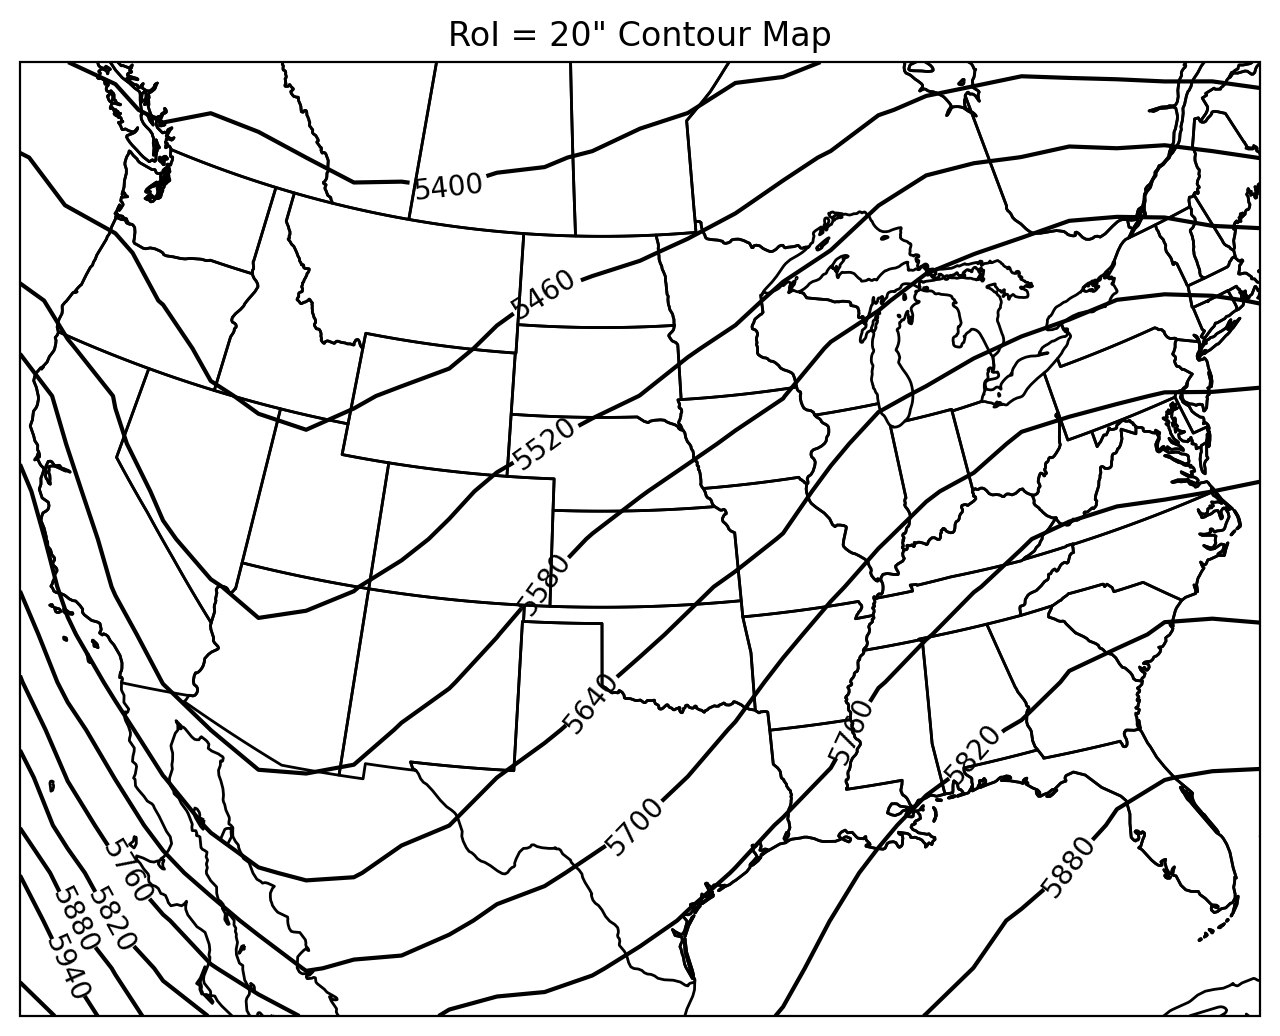

In [141]:
### Plot 500mb analyses over a map ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho*1000, semiminor_axis=rho*1000)
proj = ccrs.Stereographic(central_longitude=lam0,central_latitude=90,true_scale_latitude=60.0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax2 = fig.add_subplot(111,projection=proj)
ax2.add_feature(cfeature.STATES)
ax2.add_feature(cfeature.COASTLINE)

cs2 = ax2.contour(gyy/m/100,-gxx/m/100,Z20,colors='k',levels=np.arange(0,8000,60),transform=proj)
plt.clabel(cs2,levels=np.arange(0,8000,60))
plt.title('RoI = 20" Contour Map')
#plt.savefig('Z20_contour_map.png', dpi=300,bbox_inches='tight')
plt.show()

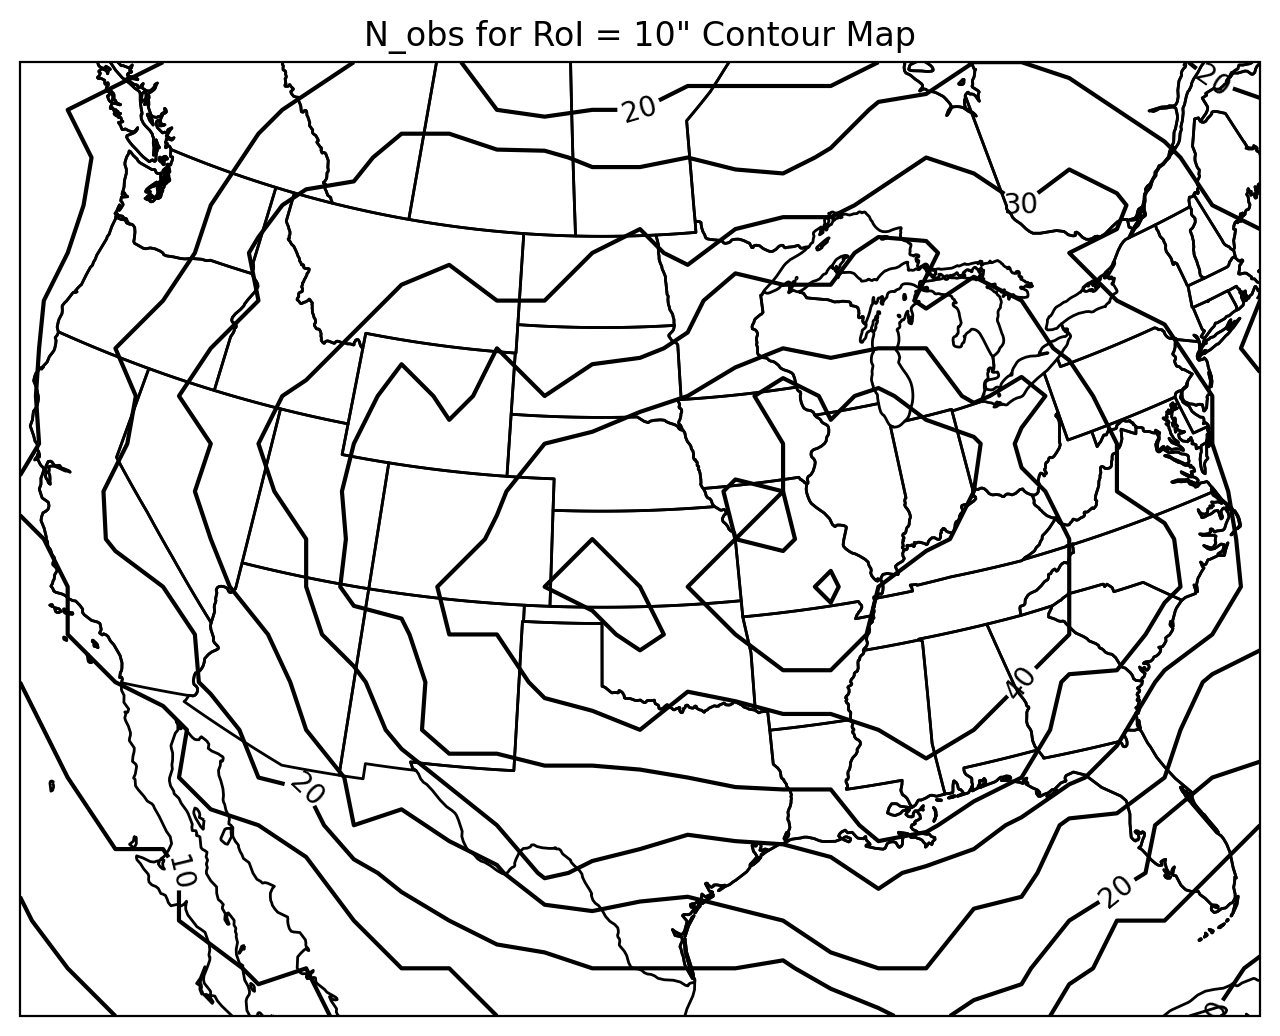

In [126]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho*1000, semiminor_axis=rho*1000)
proj = ccrs.Stereographic(central_longitude=lam0,central_latitude=90,true_scale_latitude=60.0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax3 = fig.add_subplot(111,projection=proj)
ax3.add_feature(cfeature.STATES)
ax3.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs3 = ax3.contour(gyy/m/100,-gxx/m/100,n10,colors='k',levels=np.arange(0,200,5),transform=proj)
plt.clabel(cs3,levels=np.arange(0,200,10))
plt.title('N_obs for RoI = 10" Contour Map')
#plt.savefig('n10_contour_map.png', dpi=300,bbox_inches='tight')
plt.show()

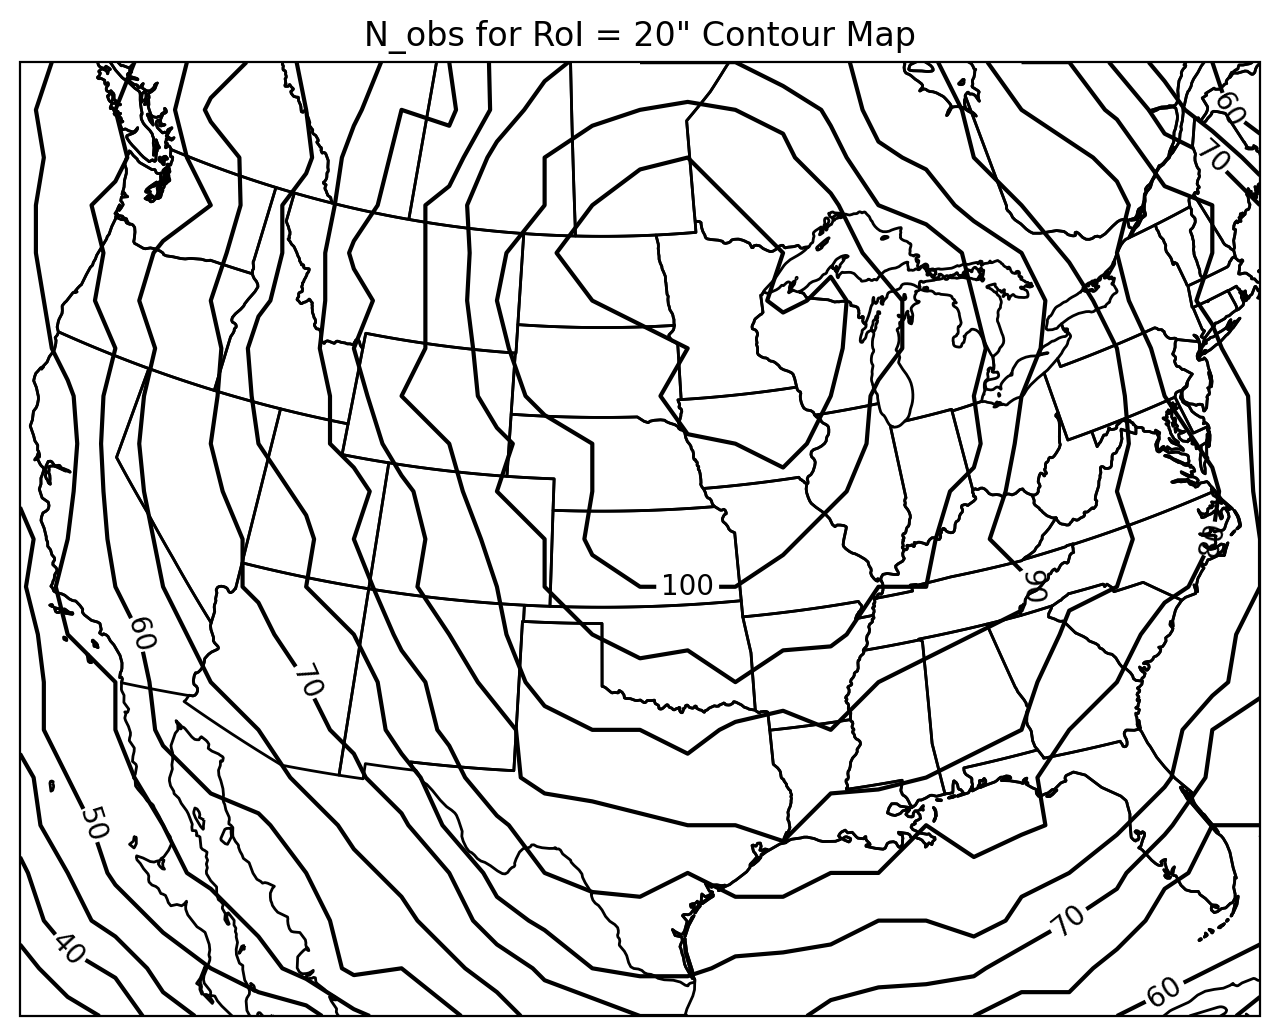

In [140]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho*1000, semiminor_axis=rho*1000)
proj = ccrs.Stereographic(central_longitude=lam0,central_latitude=90,true_scale_latitude=60.0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax4 = fig.add_subplot(111,projection=proj)
ax4.add_feature(cfeature.STATES)
ax4.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs4 = ax4.contour(gyy/m/100,-gxx/m/100,n20,colors='k',levels=np.arange(0,200,5),transform=proj)
plt.clabel(cs4,levels=np.arange(0,200,10))
plt.title('N_obs for RoI = 20" Contour Map')
#plt.savefig('n20_contour_map.png', dpi=300,bbox_inches='tight')
plt.show()

In [94]:
### Store the analyses in text files ###
for tag, Z, n in [("10cm", Z10, n10), ("20cm", Z20, n20)]:
    np.savetxt(f"analysis_{tag}.txt", Z, fmt="%.1f", delimiter=",")
    np.savetxt(f"nobs_{tag}.txt", n, fmt="%d", delimiter=",")

In [95]:
### Store the number of observations available for each grid point in text files ###

# previous cell

In [96]:
### In a separte text file (or below), answer the following questions ###
'''
1 - Describe the general features that you see in your contoured analyses.

    The contoured analyses show a trough in the western U.S. and a ridge over the eastern U.S.
    There is a closed high over the Gulf of Mexico. There's a jumble of isoheights in the 
    southwest corner of the map, but that's just a byproduct of the RoI being 10"

2 - Describe the differences that you see in your contoured analyses.  
    Does one analysis seem to be smoother than the other?  If so, what would cause this?
    
    The wave is a lot less prominent in the RoI=20 map than the 10" map. The RoI=20 map
    is a lot smoother than the RoI=10 analysis. Including more observations for each 
    analysis point will smooth out the contours. You'd be led to believe the trough is much
    stronger if you only consider the analysis with the RoIi of 10"

3 - Run your program using a radius of influence of 6 cm (do not need to show).  
    Describe the results - do they look realistic?  If there are problems, what
    do you think might be causing them?

    The contours end up cutting out in spaces due to lack of observations to provide an analysis.
    It doesn't look super realistic as it portrays a super deep trough with a tight gradient
    in geopotential height over Texas that all of a sudden drops off as you go north and west over Utah and Colorado.
    The lower spatial density of obs over the west is probably the reason for this. The contours cut off over the ocean
    where there are no observations.

4 - Suppose you ran this program with a small enough radius of influence that only one
    observation was available for determining a polynomial fit at a grid point.  Should
    you be able to perform the matrix inversion?  Why or why not?

    You would attempt to perform analysis with a singular matrix which you cannot invert
    because its determinant is zero.
    
'''

'\n1 - Describe the general features that you see in your contoured analyses.\n    \n\n2 - Describe the differences that you see in your contoured analyses.  \n    Does one analysis seem to be smoother than the other?  If so, what would cause this?\n    \n\n3 - Run your program using a radius of influence of 6 cm (do not need to show).  \n    Describe the results - do they look realistic?  If there are problems, what\n    do you think might be causing them?\n    \n\n4 - Suppose you ran this program with a small enough radius of influence that only one\n    observation was available for determining a polynomial fit at a grid point.  Should\n    you be able to perform the matrix inversion?  Why or why not?\n    \n\n'